In [1]:
import google.auth
credentials, PROJECT_ID= google.auth.default()
print(credentials)
print(PROJECT_ID)

anbc-hcb-dev


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [3]:
from google.cloud import bigquery
client = bigquery.Client()

sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_komodo_Feb_2024_June_2023_embeddings` 
"""
kmdo = client.query(sql).to_dataframe() 
kmdo.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255,individual_id
0,0.338025,0.196644,-0.444096,-0.142695,0.459136,0.458349,-0.829125,-1.191199,0.192171,-0.051398,...,-0.146023,-0.001252,-0.190597,-0.383509,1.260470,-0.449335,0.200401,-0.377429,-0.552615,461110104
1,0.108524,-0.248722,-0.985752,0.303841,-0.776847,0.891602,-0.995080,-0.960520,0.338094,-0.458783,...,0.321243,0.654438,-0.309547,-0.254308,0.859847,0.535241,-0.566751,-0.946665,-0.207197,500428731
2,0.073577,-0.697313,-1.079671,0.062164,-0.441528,1.071540,-0.785232,-0.677764,0.348427,-0.507343,...,0.301463,0.142438,-0.651206,-0.898885,0.754503,0.457670,-0.307933,-0.835107,-0.421200,480569825
3,-0.239227,-0.397605,-0.887813,-0.244378,-0.922105,0.613086,-0.581561,-0.260143,0.261774,-0.521270,...,0.218543,0.205679,-0.439209,-0.494386,1.142452,0.043947,0.109001,-0.589508,-0.626700,351487642
4,-0.409997,-0.597714,-0.763060,0.352227,-0.476281,0.913334,-0.796760,-0.962009,0.913116,-0.567380,...,0.425642,0.027671,-0.811041,-0.680795,0.713821,1.133262,0.293473,-1.116303,0.020975,500262200


In [4]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_member` 
"""
mem = client.query(sql).to_dataframe() 
mem.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group
0,480248210,48,VA,2023-06-01,DD,ABD
1,480183630,48,VA,2023-06-01,DD,ABD
2,480249646,48,VA,2023-06-01,DD,ABD
3,480236900,48,VA,2023-06-01,DD,ABD
4,480239602,48,VA,2023-06-01,DD,ABD


In [5]:
print(mem['coa_population_group'].value_counts())

TANF/CHIP    1566888
Expansion     731116
ABD           158875
BH            118451
LTSS           81785
Dual Elig      77420
Other          67490
Dual Int       46358
Name: coa_population_group, dtype: int64


In [6]:
mem = mem.rename(columns={"asdb_member_key": "individual_id"})

In [7]:
kmdo_mem = mem.merge(kmdo, on='individual_id', how='left')
kmdo_mem = kmdo_mem.assign(embed_type = 'komodo_integrated')
kmdo_mem.fillna(value = 0, inplace = True)

In [8]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_outcomes_revised` 
"""
outcomes = client.query(sql).to_dataframe() 
outcomes.head()

,asdb_member_key,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,520492042,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
1,71877926,0,0.0,0,1,1.0,0,0.0,0,0,0,0,0
2,281691075,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
3,480469230,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0
4,460895564,0,0.0,0,0,0.0,0,0.0,0,0,0,0,0


In [9]:
outcomes = outcomes.rename(columns={"asdb_member_key": "individual_id"})
kmdo_outcome = kmdo_mem.merge(outcomes, on='individual_id', how='left')

In [10]:
kmdo_outcome.columns

Index(['individual_id', 'asdb_plan_key', 'asdb_plan_nm', 'asdb_elig_dt',
       'coa_population_category', 'coa_population_group', 'emb0', 'emb1',
       'emb2', 'emb3',
       ...
       'sum_acute_calc_los', 'non_acute_ip_flag', 'sum_non_acute_ip_admits',
       'maternity_ip_flag', 'sum_maternity_ip_admits', 'sum_ed_visits',
       'ed_flag', 'sum_avoidable', 'sum_unnecessary', 'sum_preventable'],
      dtype='object', length=275)

In [11]:
#kmdo_outcome.fillna(value = 0, inplace = True)
kmdo_outcome.head()

,individual_id,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,emb0,emb1,emb2,emb3,...,sum_acute_calc_los,non_acute_ip_flag,sum_non_acute_ip_admits,maternity_ip_flag,sum_maternity_ip_admits,sum_ed_visits,ed_flag,sum_avoidable,sum_unnecessary,sum_preventable
0,480248210,48,VA,2023-06-01,DD,ABD,0.437266,-0.892022,-0.134072,-0.042579,...,0,0,0.0,0,0.0,0,0,0,0,0
1,480183630,48,VA,2023-06-01,DD,ABD,-0.608172,-0.421894,-0.949537,0.303980,...,0,0,0.0,0,0.0,0,0,0,0,0
2,480249646,48,VA,2023-06-01,DD,ABD,-0.456634,-0.512235,-0.505720,-0.050555,...,0,0,0.0,0,0.0,0,0,0,0,0
3,480236900,48,VA,2023-06-01,DD,ABD,-0.317939,-0.766088,-0.715321,-0.058599,...,0,0,0.0,0,0.0,0,0,0,0,0
4,480239602,48,VA,2023-06-01,DD,ABD,-0.444804,-1.120099,-0.613433,0.364074,...,0,0,0.0,0,0.0,1,1,1,1,0


In [12]:
print(kmdo_outcome['acute_ip_flag'].value_counts())

0    2802354
1      46029
Name: acute_ip_flag, dtype: Int64


In [13]:
kmdo_outcome = kmdo_outcome.set_index('individual_id')

In [14]:
#split dataset in features and target variable
X = kmdo_outcome.iloc[:, 5:261] # Features
y = kmdo_outcome.loc[:, 'acute_ip_flag'] # Target variable
X.head()

,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,...,emb246,emb247,emb248,emb249,emb250,emb251,emb252,emb253,emb254,emb255
individual_id,,,,,,,,,,,,,,,,,,,,,
480248210,0.437266,-0.892022,-0.134072,-0.042579,-0.904241,0.638069,-0.292417,0.472383,0.195168,-0.805676,...,-0.517088,-0.019038,0.239880,-0.631051,-0.962120,0.388730,0.550304,0.380265,-0.602271,-0.370150
480183630,-0.608172,-0.421894,-0.949537,0.303980,-0.145582,0.688361,-0.449325,-0.245733,0.554536,-0.447789,...,0.633480,0.349540,0.062546,-0.703770,-0.673745,0.648655,-0.334046,-0.132269,-0.544499,-0.499603
480249646,-0.456634,-0.512235,-0.505720,-0.050555,-0.243253,0.671369,-0.420523,-0.301576,0.152142,-0.396060,...,0.127976,0.162261,0.269647,-0.594071,-0.792085,1.107458,-0.121363,0.565026,-0.435835,-0.396365
480236900,-0.317939,-0.766088,-0.715321,-0.058599,-0.311676,0.711454,-0.537474,-0.386156,0.260317,-0.679730,...,0.319588,0.169617,0.197481,-0.866046,-0.994033,0.829467,0.235747,-0.094954,-0.970921,-0.176574
480239602,-0.444804,-1.120099,-0.613433,0.364074,-0.729414,1.162788,-0.568004,-0.470125,0.792228,-0.613803,...,0.108493,0.286307,0.099978,-1.170120,-0.851297,0.344669,0.538475,0.069888,-0.948652,-0.237915


In [15]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20)

In [17]:
# import the class
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier

# instantiate the model (using the default parameters)
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0).fit(X_train, y_train)

# fit the model with data
#clf.score(X_test, y_test)

In [63]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 11.8 MB/s eta 0:00:0000:01


In [71]:
import xgboost
import shap
# train a model with single tree
#Xd = xgboost.DMatrix(X, label=y)
#model = xgboost.train({"eta": 1, "max_depth": 3, "base_score": 0, "lambda": 0}, Xd, 1)

print("Model error =", np.linalg.norm(y_test - clf.predict(X_test)))
#print(clf.get_dump(with_stats=True)[0])


pred = clf.predict(X_test)

explainer = shap.TreeExplainer(clf)
explanation = explainer(X_test)

shap_values = explanation.values
# make sure the SHAP values add up to marginal predictions
np.abs(shap_values.sum(axis=1) + explanation.base_values - pred).max()

Model error = 198.32549004099297


1173.0943293917885

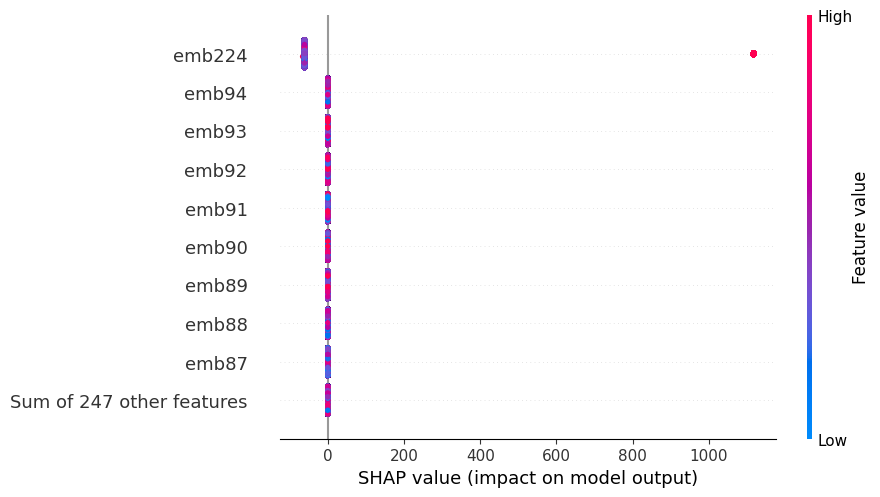

In [72]:
shap.plots.beeswarm(explanation)

In [18]:
#y_pred = clf.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)
y_pred.head()
y_pred.shape

(712096, 1)

In [19]:
threshold = 0.3

y_predict_prob =clf.predict_proba(X_test)[:, 1]
y_predict_lab = ((clf.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,668187,32321
1,7012,4576


In [21]:
from joblib import dump, load
dump(clf, 'Medicaid_IP_embeddings_only_xgb.joblib') 
#logreg = load('Medicaid_IP_embeddings_only_logreg.joblib')

['Medicaid_IP_embeddings_only_xgb.joblib']

In [22]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_predict_lab)
cnf_matrix

array([[668187,  32321],
       [  7012,   4576]])

Text(0.5, 427.9555555555555, 'Predicted label')

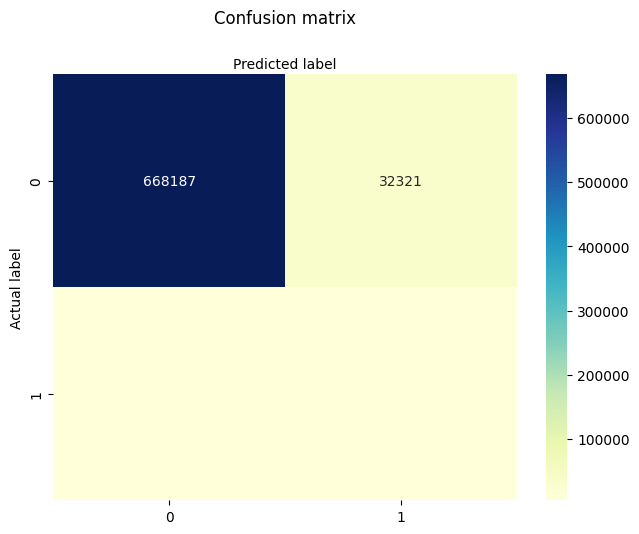

In [23]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [24]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_predict_lab, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      0.95      0.97    700508
     with IP       0.12      0.39      0.19     11588

    accuracy                           0.94    712096
   macro avg       0.56      0.67      0.58    712096
weighted avg       0.98      0.94      0.96    712096



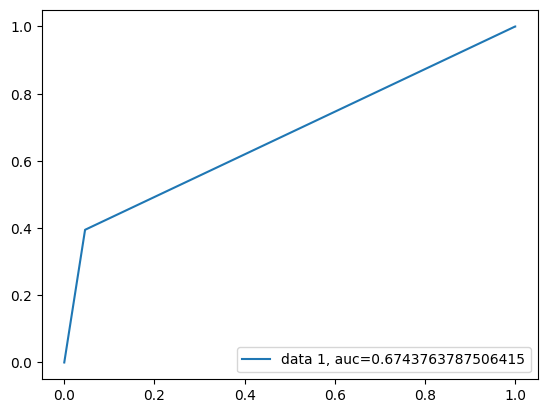

In [27]:
y_pred_proba = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

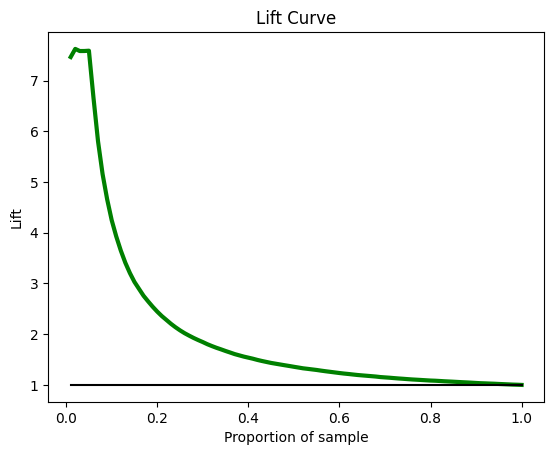

In [28]:
# Function that plots a Lift Curve using the real label values of a dataset and the probability predictions of a Machine Learning Algorithm/model
# @Params:
# y_val: real labels of the data
# y_pred: probability predictions for such data
# step: how big we want the steps in the percentiles to be

# imports
import numpy as np
import pandas as pd

def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
    
plot_lift_curve(y_test, y_pred_proba, step=0.01)

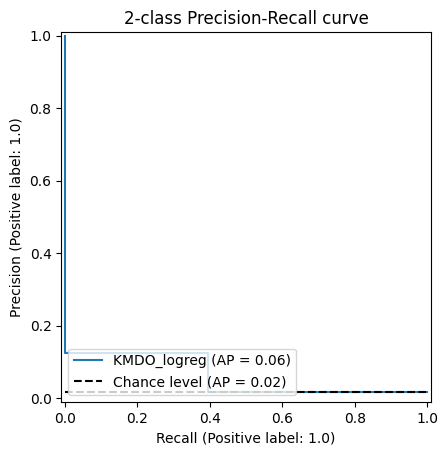

In [32]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [29]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [30]:
lift_chart(X_test, y_test, clf)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,865,7121,1.000006,7.464619,7.464619,1.000006,7.464577
1,1.000000,1.000000,902,7121,1.000006,7.783914,15.248533,2.000011,7.624224
2,1.000000,1.000000,869,7121,1.000006,7.499137,22.74767,3.000017,7.582514
3,1.000000,1.000000,879,7121,1.000006,7.585433,30.333103,4.000022,7.583233
4,1.000000,1.000000,882,7121,1.000006,7.611322,37.944425,5.000028,7.588842
...,...,...,...,...,...,...,...,...,...
95,0.010358,0.010358,74,7121,1.000006,0.638592,97.437004,95.999978,1.014969
96,0.010358,0.010358,73,7121,1.000006,0.629962,98.066966,96.999983,1.011
97,0.010358,0.010358,68,7121,1.000006,0.586814,98.65378,97.999989,1.006671
98,0.010358,0.010358,84,7121,1.000006,0.724888,99.378668,98.999994,1.003825


In [33]:
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df

In [34]:
lift_chart(X_test, y_test, clf)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.010358,4923,71210,10.000056,42.483604,42.483604,10.000056,4.248337
1,0.010358,0.010358,744,71210,10.000056,6.420435,48.904039,20.000112,2.445188
2,0.010358,0.010358,747,71209,9.999916,6.446324,55.350362,30.000028,1.84501
3,0.010358,0.010358,713,71210,10.000056,6.152917,61.503279,40.000084,1.537579
4,0.010358,0.010358,739,71209,9.999916,6.377287,67.880566,50.000000,1.357611
5,0.010358,0.010358,718,71210,10.000056,6.196065,74.076631,60.000056,1.234609
6,0.010358,0.010358,731,71209,9.999916,6.30825,80.384881,69.999972,1.148356
7,0.010358,0.010358,755,71210,10.000056,6.515361,86.900242,80.000028,1.086253
8,0.010358,0.010358,763,71209,9.999916,6.584398,93.484639,89.999944,1.038719
9,0.010358,0.000102,755,71210,10.000056,6.515361,100.0,100.000000,1.0


In [35]:
sql = """
select *
from `anbc-hcb-dev.cm_medicaid_hcb_dev.Medicaid_June_2023_tenure` 
"""
tenure = client.query(sql).to_dataframe() 
tenure.head()

,asdb_member_key,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
0,480266556,48,VA,2023-06-01,DD,ABD,13
1,480155331,48,VA,2023-06-01,DD,ABD,13
2,480325456,48,VA,2023-06-01,DD,ABD,13
3,480559161,48,VA,2023-06-01,DD,ABD,13
4,480241619,48,VA,2023-06-01,DD,ABD,13


In [36]:
tenure = tenure.rename(columns={"asdb_member_key": "individual_id"})
tenure = tenure.set_index('individual_id')

In [37]:
pd.crosstab(tenure['tenure'], tenure['coa_population_group'])

coa_population_group,ABD,BH,Dual Elig,Dual Int,Expansion,LTSS,Other,TANF/CHIP
tenure,,,,,,,,
0,1685,6575,1711,1003,9932,1424,1143,27216
1,1446,5464,1374,1139,9245,1467,1122,22299
2,1584,4703,1327,1461,11862,1447,1016,23053
3,1546,4671,1500,864,11206,1451,1087,22922
4,1573,4202,1782,850,14719,1537,1069,23926
5,4360,3981,3511,1254,38691,1398,739,59359
6,1480,3646,571,421,9631,1033,867,25653
7,1436,3017,570,559,9412,1191,896,26271
8,1380,5286,632,1035,8594,1175,1039,23517


In [38]:
tenure.head()

,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,
480266556,48,VA,2023-06-01,DD,ABD,13
480155331,48,VA,2023-06-01,DD,ABD,13
480325456,48,VA,2023-06-01,DD,ABD,13
480559161,48,VA,2023-06-01,DD,ABD,13
480241619,48,VA,2023-06-01,DD,ABD,13


In [39]:
df_out = pd.merge(y_pred, tenure, how = 'left',left_index = True, right_index = True)

In [40]:
df_out.shape
df_out.head()

,acute_ip_flag,y_predict_prob,y_predict_class,asdb_plan_key,asdb_plan_nm,asdb_elig_dt,coa_population_category,coa_population_group,tenure
individual_id,,,,,,,,,
451305636,0,0.010358,0,45,KY,2023-06-01,TANF,TANF/CHIP,13
460867729,0,0.010358,0,46,FL,2023-06-01,TANF,TANF/CHIP,13
461220032,0,0.010358,0,46,FL,2023-06-01,TANF,TANF/CHIP,8
352110789,0,0.010358,0,35,IL,2023-06-01,Expansion,Expansion,2
351505860,0,0.010358,0,35,IL,2023-06-01,Expansion,Expansion,13


In [41]:
print("% admitted post 6 months ABD: ", df_out[df_out['coa_population_group']=='ABD']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months BH: ", df_out[df_out['coa_population_group']=='BH']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Elig: ", df_out[df_out['coa_population_group']=='Dual Elig']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Dual Int: ", df_out[df_out['coa_population_group']=='Dual Int']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Exp: ", df_out[df_out['coa_population_group']=='Expansion']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months LTSS: ", df_out[df_out['coa_population_group']=='LTSS']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months Other: ", df_out[df_out['coa_population_group']=='Other']['acute_ip_flag'].mean()*100)
print("% admitted post 6 months TANF/CHIP: ", df_out[df_out['coa_population_group']=='TANF/CHIP']['acute_ip_flag'].mean()*100)

% admitted post 6 months ABD:  3.8862320664485277
% admitted post 6 months BH:  2.137027127713618
% admitted post 6 months Dual Elig:  5.945192754296331
% admitted post 6 months Dual Int:  6.062180652983459
% admitted post 6 months Exp:  1.743055100212008
% admitted post 6 months LTSS:  10.326810272588357
% admitted post 6 months Other:  0.6641933939684059
% admitted post 6 months TANF/CHIP:  0.552431207642688


In [42]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag']/len(df['acute_ip_flag'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df    

In [43]:
lift_chart(df_out[df_out['coa_population_group'].isin(['ABD'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,592,3973,10.0,38.341969,38.341969,10.0,3.834197
1,1.000000,0.010358,193,3973,10.0,12.5,50.841969,20.0,2.542098
2,0.010358,0.010358,89,3973,10.0,5.764249,56.606218,30.0,1.886874
3,0.010358,0.010358,78,3973,10.0,5.051813,61.658031,40.0,1.541451
4,0.010358,0.010358,97,3973,10.0,6.282383,67.940415,50.0,1.358808
5,0.010358,0.010358,113,3973,10.0,7.318653,75.259067,60.0,1.254318
6,0.010358,0.010358,103,3973,10.0,6.670984,81.930052,70.0,1.170429
7,0.010358,0.010358,103,3973,10.0,6.670984,88.601036,80.0,1.107513
8,0.010358,0.010358,89,3973,10.0,5.764249,94.365285,90.0,1.048503
9,0.010358,0.010358,87,3973,10.0,5.634715,100.0,100.0,1.0


In [44]:
lift_chart(df_out[df_out['coa_population_group'].isin(['BH'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,268,2953,10.001016,42.472266,42.472266,10.001016,4.246795
1,1.000000,0.010358,103,2953,10.001016,16.323296,58.795563,20.002032,2.939479
2,0.010358,0.010358,25,2952,9.997629,3.961965,62.757528,29.999661,2.091941
3,0.010358,0.010358,34,2953,10.001016,5.388273,68.1458,40.000677,1.703616
4,0.010358,0.010358,33,2953,10.001016,5.229794,73.375594,50.001693,1.467462
5,0.010358,0.010358,34,2952,9.997629,5.388273,78.763867,59.999323,1.312746
6,0.010358,0.010358,31,2953,10.001016,4.912837,83.676704,70.000339,1.195376
7,0.010358,0.010358,36,2952,9.997629,5.70523,89.381933,79.997968,1.117303
8,0.010358,0.010358,36,2953,10.001016,5.70523,95.087163,89.998984,1.056536
9,0.010358,0.010358,31,2953,10.001016,4.912837,100.0,100.000000,1.0


In [45]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Dual Elig'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,281,1938,10.001548,24.392361,24.392361,10.001548,2.438859
1,1.000000,0.010358,231,1938,10.001548,20.052083,44.444444,20.003096,2.221878
2,0.010358,0.010358,81,1937,9.996387,7.03125,51.475694,29.999484,1.715886
3,0.010358,0.010358,81,1938,10.001548,7.03125,58.506944,40.001032,1.462636
4,0.010358,0.010358,87,1938,10.001548,7.552083,66.059028,50.002580,1.321112
5,0.010358,0.010358,70,1937,9.996387,6.076389,72.135417,59.998968,1.202278
6,0.010358,0.010358,78,1938,10.001548,6.770833,78.90625,70.000516,1.127224
7,0.010358,0.010358,73,1937,9.996387,6.336806,85.243056,79.996904,1.065579
8,0.010358,0.010358,82,1938,10.001548,7.118056,92.361111,89.998452,1.026252
9,0.010358,0.010358,88,1938,10.001548,7.638889,100.0,100.000000,1.0


In [46]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Dual Int'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,200,1155,10.002598,28.571429,28.571429,10.002598,2.856401
1,1.000000,0.010358,154,1155,10.002598,22.0,50.571429,20.005196,2.527915
2,0.010358,0.010358,29,1154,9.993938,4.142857,54.714286,29.999134,1.823862
3,0.010358,0.010358,45,1155,10.002598,6.428571,61.142857,40.001732,1.528505
4,0.010358,0.010358,39,1155,10.002598,5.571429,66.714286,50.004330,1.33417
5,0.010358,0.010358,49,1154,9.993938,7.0,73.714286,59.998268,1.228607
6,0.010358,0.010358,46,1155,10.002598,6.571429,80.285714,70.000866,1.146925
7,0.010358,0.010358,42,1154,9.993938,6.0,86.285714,79.994804,1.078641
8,0.010358,0.010358,51,1155,10.002598,7.285714,93.571429,89.997402,1.039713
9,0.010358,0.010358,45,1155,10.002598,6.428571,100.0,100.000000,1.0


In [47]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Expansion'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.010358,1086,18302,10.000437,34.043887,34.043887,10.000437,3.40424
1,0.010358,0.010358,253,18301,9.999891,7.931034,41.974922,20.000328,2.098712
2,0.010358,0.010358,228,18301,9.999891,7.147335,49.122257,30.000219,1.637397
3,0.010358,0.010358,228,18301,9.999891,7.147335,56.269592,40.000109,1.406736
4,0.010358,0.010358,222,18301,9.999891,6.959248,63.22884,50.000000,1.264577
5,0.010358,0.010358,216,18301,9.999891,6.77116,70.0,59.999891,1.166669
6,0.010358,0.010358,206,18301,9.999891,6.45768,76.45768,69.999781,1.092256
7,0.010358,0.010358,230,18301,9.999891,7.210031,83.667712,79.999672,1.045851
8,0.010358,0.010358,244,18301,9.999891,7.648903,91.316614,89.999563,1.014634
9,0.010358,0.010358,277,18302,10.000437,8.683386,100.0,100.000000,1.0


In [48]:
lift_chart(df_out[df_out['coa_population_group'].isin(['LTSS'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,1.000000,322,2029,10.001479,15.369928,15.369928,10.001479,1.536766
1,1.000000,1.000000,347,2029,10.001479,16.563246,31.933174,20.002958,1.596423
2,1.000000,1.000000,326,2028,9.996550,15.560859,47.494033,29.999507,1.58316
3,1.000000,0.010358,320,2029,10.001479,15.274463,62.768496,40.000986,1.569174
4,0.010358,0.010358,114,2029,10.001479,5.441527,68.210024,50.002465,1.364133
5,0.010358,0.010358,131,2028,9.996550,6.252983,74.463007,59.999014,1.241071
6,0.010358,0.010358,123,2029,10.001479,5.871122,80.334129,70.000493,1.147622
7,0.010358,0.010358,138,2028,9.996550,6.587112,86.921241,79.997042,1.086556
8,0.010358,0.010358,139,2029,10.001479,6.634845,93.556086,89.998521,1.039529
9,0.010358,0.010358,135,2029,10.001479,6.443914,100.0,100.000000,1.0


In [49]:
lift_chart(df_out[df_out['coa_population_group'].isin(['Other'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.010358,26,1672,10.004787,23.423423,23.423423,10.004787,2.341222
1,0.010358,0.010358,12,1671,9.998803,10.810811,34.234234,20.003590,1.711404
2,0.010358,0.010358,3,1671,9.998803,2.702703,36.936937,30.002393,1.231133
3,0.010358,0.010358,11,1671,9.998803,9.90991,46.846847,40.001197,1.171136
4,0.010358,0.010358,5,1671,9.998803,4.504505,51.351351,50.000000,1.027027
5,0.010358,0.010358,10,1671,9.998803,9.009009,60.36036,59.998803,1.006026
6,0.010358,0.010358,15,1671,9.998803,13.513514,73.873874,69.997607,1.055377
7,0.010358,0.010358,9,1671,9.998803,8.108108,81.981982,79.996410,1.024821
8,0.010358,0.010358,8,1671,9.998803,7.207207,89.189189,89.995213,0.991044
9,0.010358,0.010358,12,1672,10.004787,10.810811,100.0,100.000000,1.0


In [50]:
lift_chart(df_out[df_out['coa_population_group'].isin(['TANF/CHIP'])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,1.000000,0.010358,526,39191,10.000153,24.295612,24.295612,10.000153,2.429524
1,0.010358,0.010358,191,39190,9.999898,8.822171,33.117783,20.000051,1.655885
2,0.010358,0.010358,202,39190,9.999898,9.330254,42.448037,29.999949,1.414937
3,0.010358,0.010358,176,39191,10.000153,8.12933,50.577367,40.000102,1.264431
4,0.010358,0.010358,193,39190,9.999898,8.91455,59.491917,50.000000,1.189838
5,0.010358,0.010358,185,39190,9.999898,8.545035,68.036952,59.999898,1.133951
6,0.010358,0.010358,179,39191,10.000153,8.267898,76.30485,70.000051,1.090068
7,0.010358,0.010358,193,39190,9.999898,8.91455,85.2194,79.999949,1.065243
8,0.010358,0.010358,159,39190,9.999898,7.344111,92.56351,89.999847,1.028485
9,0.010358,0.000102,161,39191,10.000153,7.43649,100.0,100.000000,1.0


In [51]:
ABD = df_out.loc[df_out['coa_population_group'].isin(['ABD'])]
BH = df_out.loc[df_out['coa_population_group'].isin(['BH'])]
D_Elig = df_out.loc[df_out['coa_population_group'].isin(['Dual Elig'])]
D_Int = df_out.loc[df_out['coa_population_group'].isin(['Dual Int'])]
Exp = df_out.loc[df_out['coa_population_group'].isin(['Expansion'])]
LTSS = df_out.loc[df_out['coa_population_group'].isin(['LTSS'])]
Oth = df_out.loc[df_out['coa_population_group'].isin(['Other'])]
T_C = df_out.loc[df_out['coa_population_group'].isin(['TANF/CHIP'])]

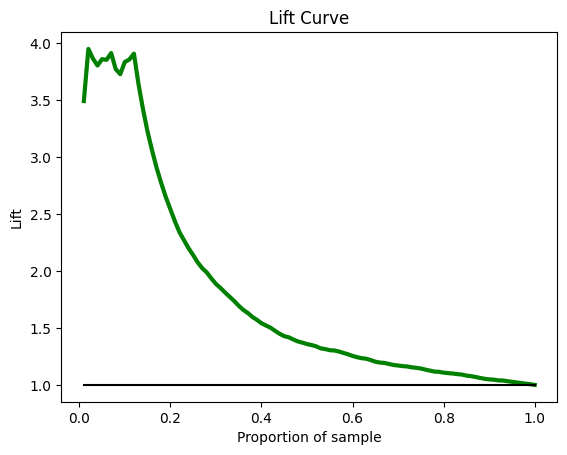

In [52]:
plot_lift_curve(ABD['acute_ip_flag'], ABD['y_predict_class'], step=0.01)

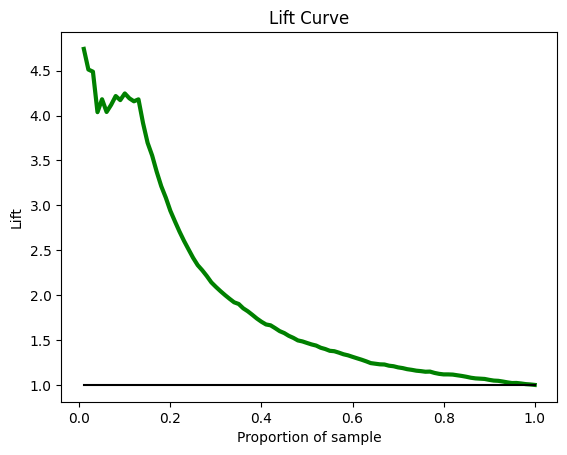

In [53]:
plot_lift_curve(BH['acute_ip_flag'], BH['y_predict_class'], step=0.01)

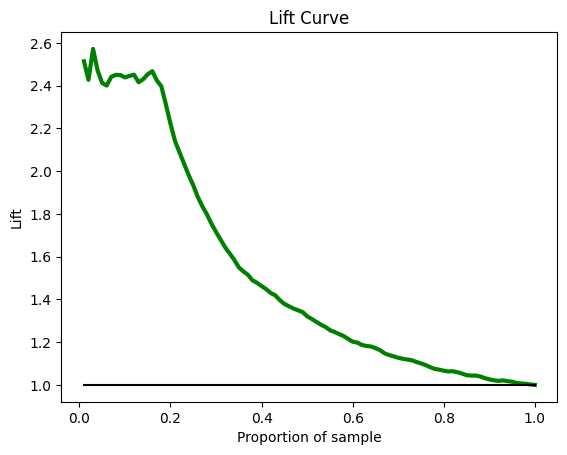

In [54]:
plot_lift_curve(D_Elig['acute_ip_flag'], D_Elig['y_predict_class'], step=0.01)

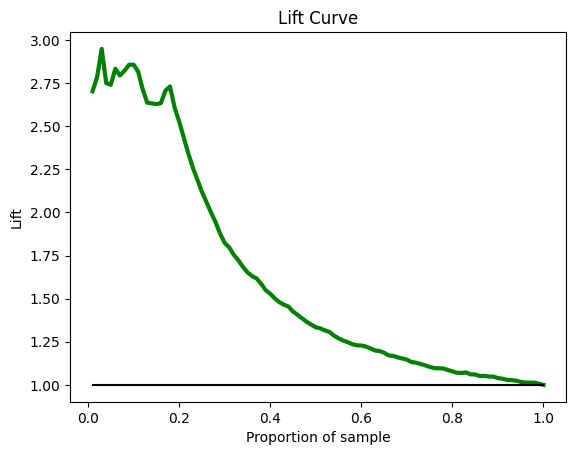

In [55]:
plot_lift_curve(D_Int['acute_ip_flag'], D_Int['y_predict_class'], step=0.01)

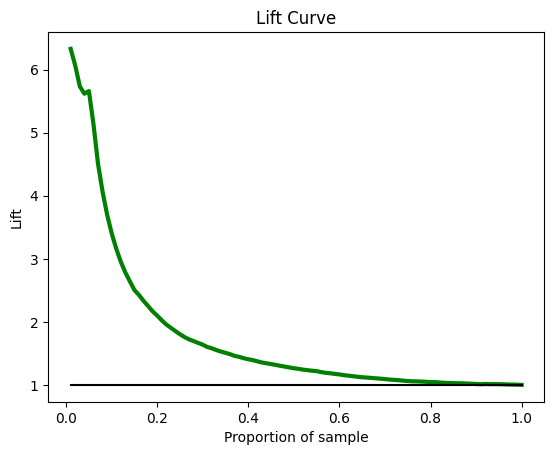

In [56]:
plot_lift_curve(Exp['acute_ip_flag'], Exp['y_predict_class'], step=0.01)

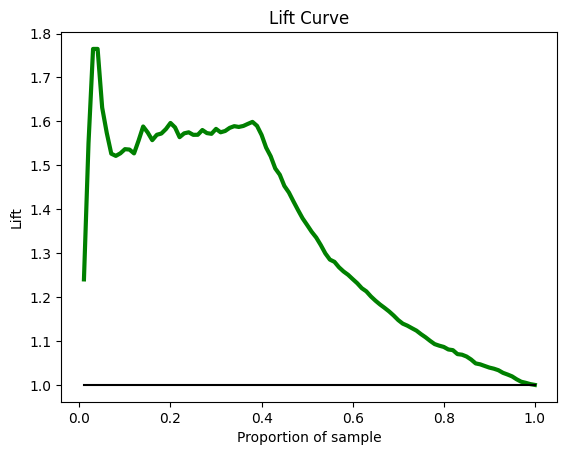

In [57]:
plot_lift_curve(LTSS['acute_ip_flag'], LTSS['y_predict_class'], step=0.01)

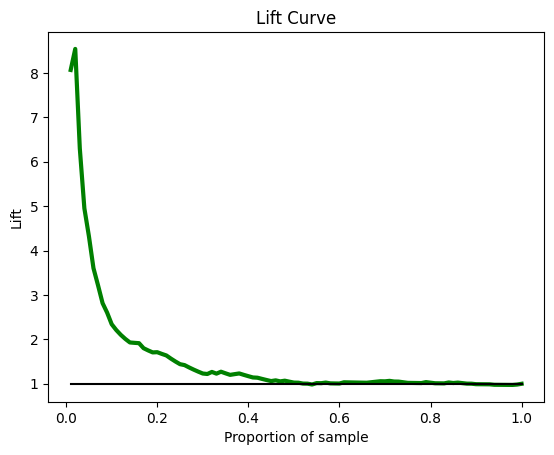

In [58]:
plot_lift_curve(Oth['acute_ip_flag'], Oth['y_predict_class'], step=0.01)

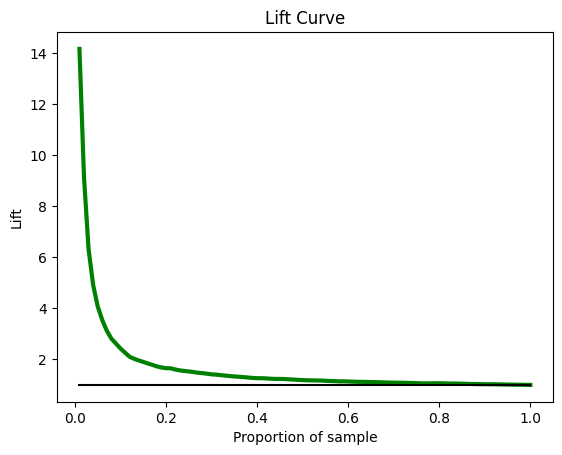

In [59]:
plot_lift_curve(T_C['acute_ip_flag'], T_C['y_predict_class'], step=0.01)